# Laboratorio 1. Series de Tiempo

## Modelado de las series regionales

Fernando Rueda - 23748

Fernando Hernández - 23645

Este cuaderno cubre el inciso 4g del enunciado para las cuatro series de las que somos
responsables: el total de visitantes (serie obligatoria) y las tres regiones de `region_dos`,
América Del Centro, América Del Norte y Europa. Para cada una ajustamos una rejilla de modelos
SARIMA, comparamos por AIC, BIC y comportamiento de los residuos, y contrastamos con la
propuesta automática de `auto_arima`.

Parte del diagnóstico del cuaderno `analisis-series.ipynb`, que dejó como candidato de partida un
SARIMA(0,1,1)(0,1,1)₁₂ sobre el logaritmo, con d = 1 y período estacional 12 en las cuatro
series. Las dos regiones con meses en cero de 2020, América Del Norte y Europa, se modelan sobre
log(1 + x). Los algoritmos alternativos, la predicción sobre la prueba y la comparación por
métricas quedan para el cuaderno siguiente.

In [1]:
import sys
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pmdarima as pm
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.tsa.statespace.sarimax import SARIMAX

warnings.filterwarnings("ignore")  # los SARIMA de la rejilla avisan sobre convergencia sin afectar el resultado

RAIZ = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
FIGURAS = RAIZ / "reports" / "figuras"
FIGURAS.mkdir(parents=True, exist_ok=True)

PALETA = ["#2a78d6", "#eb6834", "#1baf7a", "#eda100", "#e87ba4"]
AZUL, NARANJA, AQUA, AMARILLO, MAGENTA = PALETA
GRIS = "#8a8a85"

plt.rcParams.update({
    "figure.figsize": (11, 4.2),
    "figure.dpi": 110,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.color": "#e4e4e0",
    "grid.linewidth": 0.8,
    "axes.axisbelow": True,
    "axes.titlesize": 12,
    "axes.titleweight": "semibold",
    "font.size": 10,
    "legend.frameon": False,
})

def guardar(nombre):
    plt.tight_layout()
    plt.savefig(FIGURAS / f"{nombre}.png", bbox_inches="tight", facecolor="white")

pd.set_option("display.width", 160)

In [2]:
train = pd.read_csv(RAIZ / "data" / "processed" / "series_train.csv", parse_dates=["fecha"]).set_index("fecha").asfreq("MS")

# El total y América Del Centro no tienen ceros y van sobre log; Norte y Europa traen los cinco
# meses en cero del cierre de 2020 y van sobre log(1 + x), como fijó el análisis preliminar.
SERIES = {
    "total": np.log(train["total"]),
    "region: América Del Centro": np.log(train["region: América Del Centro"]),
    "region: América Del Norte": np.log1p(train["region: América Del Norte"]),
    "region: Europa": np.log1p(train["region: Europa"]),
}
print(f"Entrenamiento: {train.index.min():%Y-%m} a {train.index.max():%Y-%m}, {len(train)} meses")
for nombre, y in SERIES.items():
    print(f"  {nombre:32s} transform={'log1p' if 'Norte' in nombre or 'Europa' in nombre else 'log'}")

Entrenamiento: 2009-01 a 2021-03, 147 meses
  total                            transform=log
  region: América Del Centro       transform=log
  region: América Del Norte        transform=log1p
  region: Europa                   transform=log1p


## 1. Metodología

**Candidatos.** El análisis preliminar dejó como punto de partida el SARIMA(0,1,1)(0,1,1)₁₂
sobre el log, con la parte regular sugerida por el rezago 1 negativo de los correlogramas y la
estacional por el rezago 12. Alrededor de ese candidato ajustamos la misma rejilla de nueve
modelos que se usó en las fronteras, para que la comparación sea homogénea entre las siete
series: variantes AR contra MA en la parte regular (p, q en {0, 1, 2}), variantes AR contra MA
en la estacional (P, Q en {0, 1}), y dos variantes con D = 0 para las series donde el análisis
preliminar dejó la diferencia estacional como opcional.

**Comparación.** AIC y BIC comparan el ajuste penalizando parámetros. Solo son comparables entre
modelos con la misma diferenciación, porque cambiar d o D cambia la serie sobre la que se calcula
la verosimilitud; por eso los modelos con D = 0 se evalúan aparte. El segundo criterio es la
prueba de Ljung-Box sobre los residuos: un buen modelo deja residuos sin autocorrelación
(p > 0.05 significa residuos compatibles con ruido blanco).

**Advertencia sobre el tramo pandémico.** Los últimos doce meses del entrenamiento son el
colapso de 2020. Ningún SARIMA con estacionalidad fija puede seguir una caída de esa magnitud,
así que los residuos de 2020 van a ser grandes en todas las especificaciones. El caso es más
severo en América Del Norte y Europa, cuyos cinco meses en cero se vuelven, en escala log(1 + x),
cinco residuos enormes: el modelo predice un nivel normal y la serie vale cero. Eso no distingue
entre candidatos, los castiga a todos por igual, pero sí contamina las pruebas de residuos, como
se verá en esas dos series.

In [3]:
CANDIDATOS = [
    ((0, 1, 1), (0, 1, 1, 12)),
    ((1, 1, 0), (0, 1, 1, 12)),
    ((1, 1, 1), (0, 1, 1, 12)),
    ((0, 1, 2), (0, 1, 1, 12)),
    ((0, 1, 1), (1, 1, 0, 12)),
    ((0, 1, 1), (0, 1, 0, 12)),
    ((0, 1, 2), (0, 1, 0, 12)),
    ((0, 1, 1), (1, 0, 1, 12)),   # D = 0
    ((1, 1, 1), (1, 0, 1, 12)),   # D = 0
]


def etiqueta(orden, sorden):
    return f"SARIMA{orden}x{sorden[:3]}12"


def ajustar_rejilla(y):
    """Ajusta los candidatos y devuelve la tabla de comparación y los resultados."""
    filas, ajustes = [], {}
    for orden, sorden in CANDIDATOS:
        r = SARIMAX(y, order=orden, seasonal_order=sorden).fit(disp=False)
        resid = r.resid[r.loglikelihood_burn:]
        filas.append({
            "modelo": etiqueta(orden, sorden),
            "D": sorden[1],
            "AIC": round(r.aic, 1),
            "BIC": round(r.bic, 1),
            "Ljung-Box p (12)": round(acorr_ljungbox(resid, lags=[12]).iloc[0, 1], 3),
            "Ljung-Box p (24)": round(acorr_ljungbox(resid, lags=[24]).iloc[0, 1], 3),
        })
        ajustes[etiqueta(orden, sorden)] = r
    tabla = pd.DataFrame(filas).set_index("modelo").sort_values(["D", "AIC"], ascending=[False, True])
    return tabla, ajustes


def diagnostico_residuos(resultado, titulo, nombre_figura):
    fig = resultado.plot_diagnostics(figsize=(11, 7), lags=24)
    fig.suptitle(titulo, y=1.0)
    guardar(nombre_figura)
    plt.show()

## 2. Total de visitantes

### 2.1 Rejilla de modelos SARIMA

In [4]:
tabla_total, ajustes_total = ajustar_rejilla(SERIES["total"])
tabla_total

,D,AIC,BIC,Ljung-Box p (12),Ljung-Box p (24)
modelo,,,,,
"SARIMA(0, 1, 1)x(1, 1, 0)12",1,64.1,72.8,0.215,0.856
"SARIMA(1, 1, 0)x(0, 1, 1)12",1,67.9,76.6,0.173,0.796
"SARIMA(0, 1, 1)x(0, 1, 1)12",1,68.0,76.7,0.169,0.793
"SARIMA(0, 1, 2)x(0, 1, 1)12",1,69.2,80.8,0.261,0.870
"SARIMA(1, 1, 1)x(0, 1, 1)12",1,69.6,81.2,0.206,0.829
"SARIMA(0, 1, 1)x(0, 1, 0)12",1,87.8,93.6,0.053,0.417
"SARIMA(0, 1, 2)x(0, 1, 0)12",1,88.8,97.5,0.083,0.504
"SARIMA(0, 1, 1)x(1, 0, 1)12",0,67.2,79.1,0.420,0.933
"SARIMA(1, 1, 1)x(1, 0, 1)12",0,69.1,84.0,0.447,0.941


Entre los modelos con D = 1, comparables entre sí, el mejor AIC es el
**SARIMA(0,1,1)(1,1,0)₁₂** con 64.1, claramente por delante del airline SARIMA(0,1,1)(0,1,1)₁₂
(68.0) y del SARIMA(1,1,0)(0,1,1)₁₂ (67.9). El BIC ordena igual y agregar órdenes solo empeora el
criterio. El modelo sin ningún término estacional, SARIMA(0,1,1)(0,1,0)₁₂, salta a 87.8: hay
estructura estacional que el término AR estacional sí captura.

El mejor D = 0, SARIMA(0,1,1)(1,0,1)₁₂ con AIC 67.2, no le gana al mejor D = 1 pese a tener
residuos algo más limpios (Ljung-Box 0.420), así que nos quedamos con D = 1. Y a diferencia de
varias fronteras, aquí los residuos aprueban con holgura: **Ljung-Box de 0.215 en el rezago 12 y
0.856 en el 24**. El total es una de las series mejor comportadas.

### 2.2 Residuos del modelo elegido

findfont: Failed to find font weight semibold, now using 700.


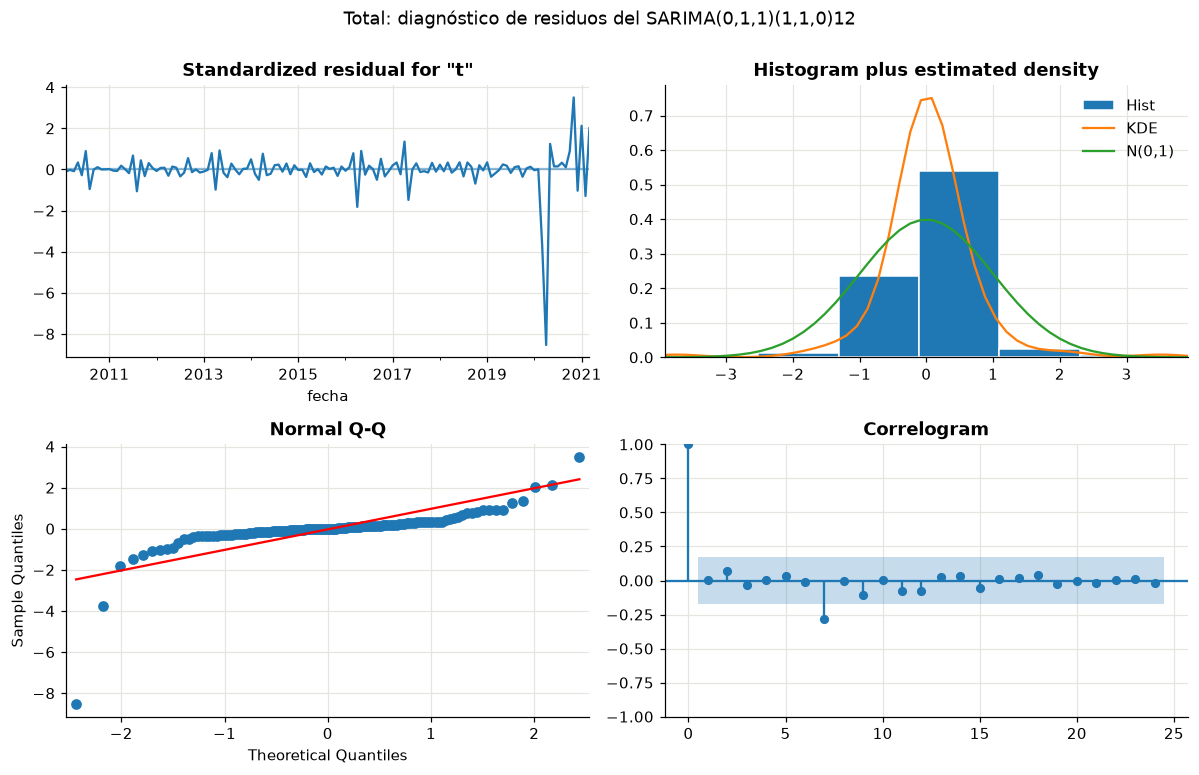

Los tres residuos más grandes (en log):
fecha
2020-04-01    2.50
2020-03-01    1.09
2020-11-01    1.02


In [5]:
mejor_total = ajustes_total["SARIMA(0, 1, 1)x(1, 1, 0)12"]
diagnostico_residuos(mejor_total, "Total: diagnóstico de residuos del SARIMA(0,1,1)(1,1,0)12",
                     "modelado-total-residuos")
resid = mejor_total.resid[mejor_total.loglikelihood_burn:]
print("Los tres residuos más grandes (en log):")
print(resid.abs().nlargest(3).round(2).to_string())

El residuo dominante es **abril de 2020 con 2.5 desviaciones**, el primer mes pleno del cierre,
seguido de marzo y noviembre de 2020, todos por debajo de las magnitudes que veremos en las
regiones con ceros. El correlograma de residuos queda dentro de la banda y el QQ-plot es
razonablemente recto salvo las colas de 2020. La autocorrelación residual no es problema aquí.

**Elegido para el total: SARIMA(0,1,1)(1,1,0)₁₂ sobre el log.** Interpretación: tras quitar
tendencia (d = 1) y estacionalidad (D = 1), cada mes se corrige con el error del mes anterior
(término MA regular) y con lo ocurrido el mismo mes del año pasado (término AR estacional).

### 2.3 Contraste con auto_arima

In [6]:
auto_total = pm.auto_arima(SERIES["total"], seasonal=True, m=12,
                           stepwise=True, suppress_warnings=True, error_action="ignore")
print(f"Propuesta de auto_arima: ARIMA{auto_total.order}x{auto_total.seasonal_order} | AIC {auto_total.aic():.1f}")
auto_total.summary().tables[1]

Propuesta de auto_arima: ARIMA(1, 0, 1)x(1, 0, 2, 12) | AIC 66.2


,coef,std err,z,P>|z|,[0.025,0.975]
intercept,0.0720,0.144,0.499,0.618,-0.211,0.355
ar.L1,0.9031,0.036,24.961,0.000,0.832,0.974
ma.L1,0.1431,0.094,1.516,0.129,-0.042,0.328
ar.S.L12,0.9376,0.122,7.691,0.000,0.699,1.177
ma.S.L12,-0.9238,0.277,-3.335,0.001,-1.467,-0.381
ma.S.L24,0.2049,0.297,0.691,0.490,-0.376,0.786
sigma2,0.0773,0.006,12.723,0.000,0.065,0.089


`auto_arima` propone un ARIMA(1,0,1)(1,0,2)₁₂ con **d = 0 y D = 0**. Es el mismo error que se vio
en las fronteras: su prueba de raíz unitaria por defecto (KPSS) lee el colapso pandémico como
ausencia de tendencia y no diferencia, compensando con partes AR y MA sobre una serie que sí
tiene tendencia. Su AIC (66.2) ni siquiera es comparable con el nuestro, porque se calcula sobre
una serie distinta, la no diferenciada. Nuestro diagnóstico manual con ADF más correlogramas
produjo un modelo más simple y correctamente diferenciado.

## 3. América Del Centro

### 3.1 Rejilla de modelos SARIMA

In [7]:
tabla_centro, ajustes_centro = ajustar_rejilla(SERIES["region: América Del Centro"])
tabla_centro

,D,AIC,BIC,Ljung-Box p (12),Ljung-Box p (24)
modelo,,,,,
"SARIMA(0, 1, 1)x(1, 1, 0)12",1,50.4,59.1,0.268,0.855
"SARIMA(0, 1, 1)x(0, 1, 1)12",1,55.5,64.2,0.205,0.763
"SARIMA(1, 1, 0)x(0, 1, 1)12",1,55.5,64.2,0.206,0.763
"SARIMA(0, 1, 2)x(0, 1, 1)12",1,57.3,68.9,0.241,0.790
"SARIMA(1, 1, 1)x(0, 1, 1)12",1,57.4,69.0,0.218,0.773
"SARIMA(0, 1, 1)x(0, 1, 0)12",1,76.8,82.5,0.050,0.287
"SARIMA(0, 1, 2)x(0, 1, 0)12",1,77.9,86.6,0.084,0.368
"SARIMA(0, 1, 1)x(1, 0, 1)12",0,54.6,66.5,0.366,0.870
"SARIMA(1, 1, 1)x(1, 0, 1)12",0,56.6,71.5,0.367,0.870


Mismo cuadro que el total, y más marcado. El **SARIMA(0,1,1)(1,1,0)₁₂** gana con AIC 50.4, cinco
puntos por delante del siguiente (55.5), una diferencia esta vez sí concluyente. El BIC coincide
y los residuos aprueban con holgura (**Ljung-Box 0.268 en el 12, 0.855 en el 24**). Los modelos
D = 0 no compiten. Que la región que aporta el 73% del total elija exactamente el mismo modelo
que el total no sorprende: el total hereda su forma.

### 3.2 Residuos del modelo elegido

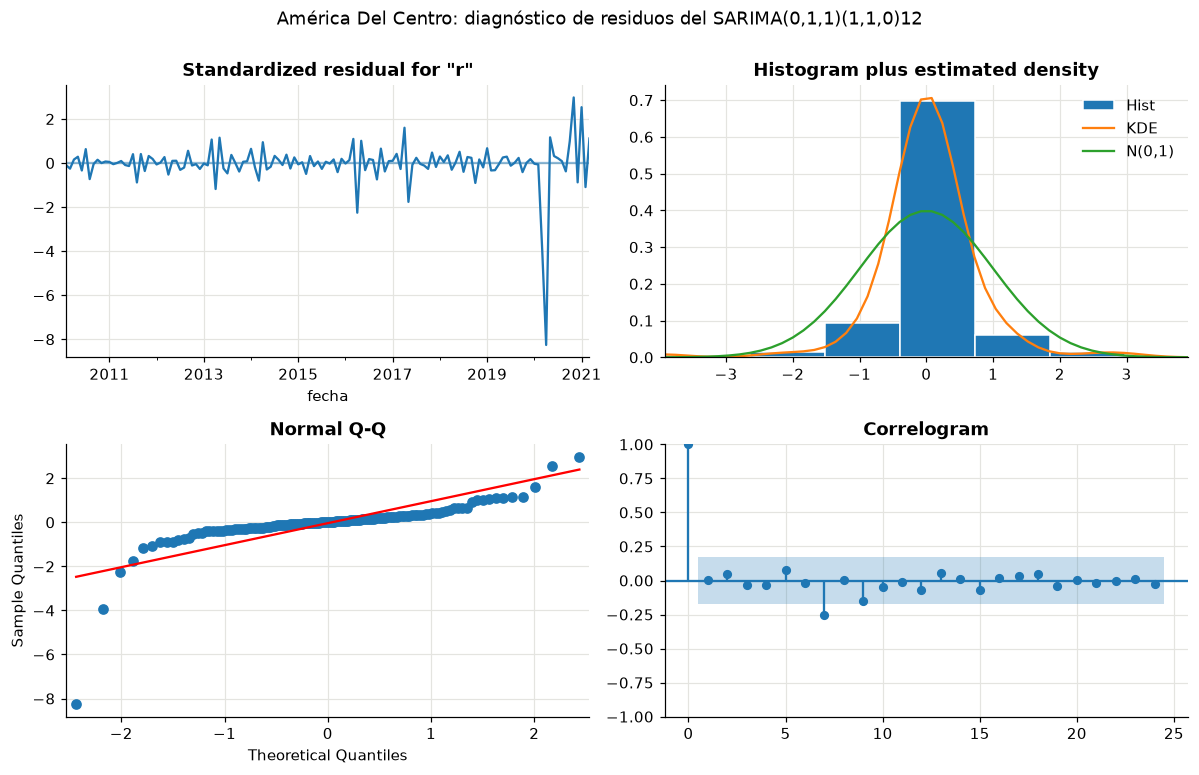

Los tres residuos más grandes (en log):
fecha
2020-04-01    2.30
2020-03-01    1.10
2020-11-01    0.83


In [8]:
mejor_centro = ajustes_centro["SARIMA(0, 1, 1)x(1, 1, 0)12"]
diagnostico_residuos(mejor_centro, "América Del Centro: diagnóstico de residuos del SARIMA(0,1,1)(1,1,0)12",
                     "modelado-centro-residuos")
resid = mejor_centro.resid[mejor_centro.loglikelihood_burn:]
print("Los tres residuos más grandes (en log):")
print(resid.abs().nlargest(3).round(2).to_string())

Residuos casi calcados a los del total, con abril de 2020 (2.3 desviaciones) a la cabeza y el
resto del correlograma limpio. Nada que el modelo deje sin capturar fuera del cambio de régimen.

**Elegido para América Del Centro: SARIMA(0,1,1)(1,1,0)₁₂ sobre el log.**

### 3.3 Contraste con auto_arima

In [9]:
auto_centro = pm.auto_arima(SERIES["region: América Del Centro"], seasonal=True, m=12,
                            stepwise=True, suppress_warnings=True, error_action="ignore")
print(f"Propuesta de auto_arima: ARIMA{auto_centro.order}x{auto_centro.seasonal_order} | AIC {auto_centro.aic():.1f}")
auto_centro.summary().tables[1]

Propuesta de auto_arima: ARIMA(1, 0, 1)x(1, 0, 2, 12) | AIC 54.1


,coef,std err,z,P>|z|,[0.025,0.975]
intercept,0.1247,0.180,0.694,0.488,-0.228,0.477
ar.L1,0.8966,0.038,23.645,0.000,0.822,0.971
ma.L1,0.1397,0.094,1.482,0.138,-0.045,0.324
ar.S.L12,0.8942,0.154,5.807,0.000,0.592,1.196
ma.S.L12,-0.7720,0.297,-2.601,0.009,-1.354,-0.190
ma.S.L24,0.1773,0.304,0.583,0.560,-0.419,0.773
sigma2,0.0728,0.006,11.397,0.000,0.060,0.085


Otra vez `auto_arima` cae en d = 0 (ARIMA(1,0,1)(1,0,2)₁₂), por la misma lectura errónea de la
tendencia. La supervisión manual vuelve a ser necesaria: con un cambio de régimen en la serie, la
selección automática necesita que se le fije la diferenciación.

## 4. América Del Norte

### 4.1 Rejilla de modelos SARIMA

In [10]:
tabla_norte, ajustes_norte = ajustar_rejilla(SERIES["region: América Del Norte"])
tabla_norte

,D,AIC,BIC,Ljung-Box p (12),Ljung-Box p (24)
modelo,,,,,
"SARIMA(0, 1, 1)x(0, 1, 0)12",1,412.2,418.0,0.0,0.025
"SARIMA(0, 1, 2)x(0, 1, 0)12",1,412.8,421.5,0.0,0.055
"SARIMA(1, 1, 0)x(0, 1, 1)12",1,413.0,421.7,0.0,0.023
"SARIMA(0, 1, 1)x(1, 1, 0)12",1,413.0,421.7,0.0,0.024
"SARIMA(0, 1, 1)x(0, 1, 1)12",1,413.1,421.8,0.0,0.025
"SARIMA(0, 1, 2)x(0, 1, 1)12",1,413.8,425.4,0.0,0.053
"SARIMA(1, 1, 1)x(0, 1, 1)12",1,414.7,426.3,0.0,0.026
"SARIMA(0, 1, 1)x(1, 0, 1)12",0,439.2,451.1,0.0,0.034
"SARIMA(1, 1, 1)x(1, 0, 1)12",0,440.8,455.7,0.0,0.038


Aquí el cuadro cambia por los ceros. Entre los D = 1 gana el modelo **más simple**,
SARIMA(0,1,1)(0,1,0)₁₂ con AIC 412.2, y los siguientes seis quedan todos en un punto (412.8 a
413.8): el término AR o MA estacional no aporta ajuste apreciable, porque la diferencia estacional
ya absorbió la estacionalidad y no queda estructura estacional que modelar. Aun así los D = 1 le
ganan claramente a los D = 0 (439), así que la diferencia estacional que el preliminar dejó como
opcional queda confirmada como conveniente por AIC.

Lo que no aprueba son los residuos: **Ljung-Box da 0.0 en el rezago 12 para todos los
candidatos**. Ningún orden lo arregla porque la causa no es el orden, es el bloque de cinco meses
en cero, como se ve abajo.

### 4.2 Residuos del modelo elegido

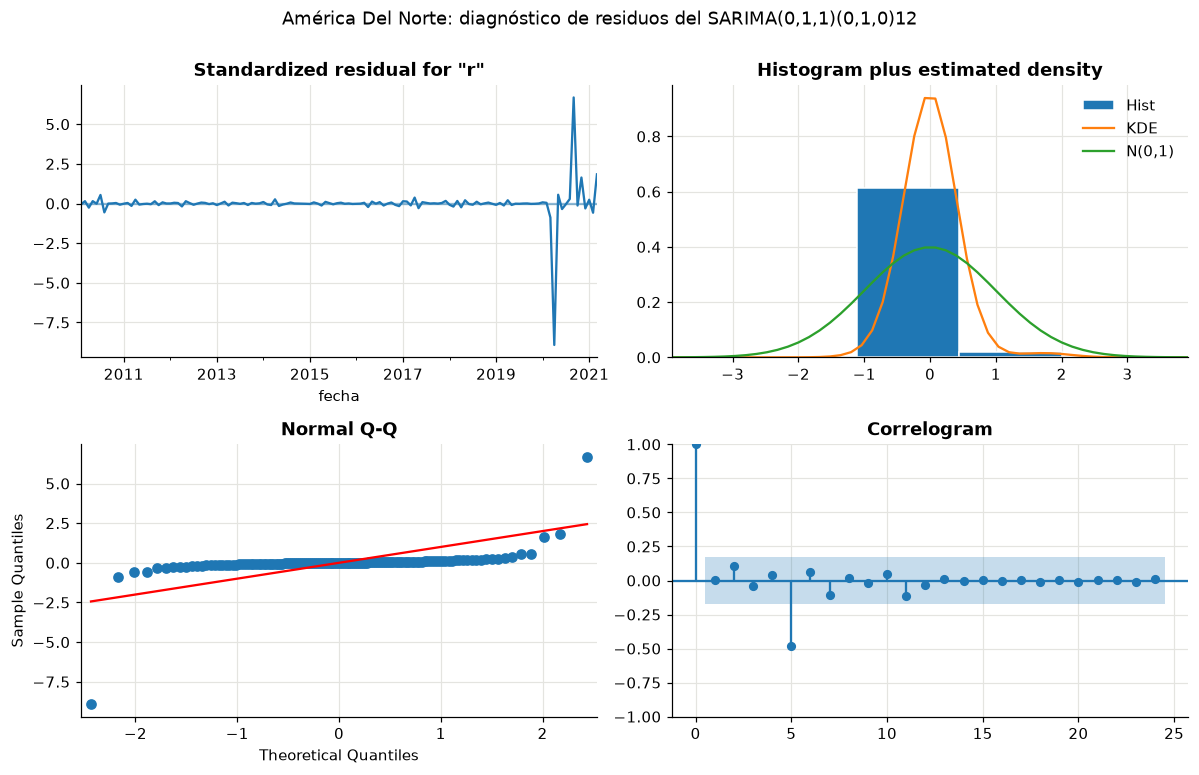

Los tres residuos más grandes (en log(1+x)):
fecha
2020-04-01    9.90
2020-09-01    7.42
2021-03-01    2.04


In [11]:
mejor_norte = ajustes_norte["SARIMA(0, 1, 1)x(0, 1, 0)12"]
diagnostico_residuos(mejor_norte, "América Del Norte: diagnóstico de residuos del SARIMA(0,1,1)(0,1,0)12",
                     "modelado-norte-residuos")
resid = mejor_norte.resid[mejor_norte.loglikelihood_burn:]
print("Los tres residuos más grandes (en log(1+x)):")
print(resid.abs().nlargest(3).round(2).to_string())

Los residuos gigantes lo explican todo: **abril de 2020 con 9.9 desviaciones y septiembre con
7.4**, los meses en cero, donde el modelo predice el nivel normal en log(1 + x) y la serie vale
cero. Cinco residuos de ese tamaño, correlacionados entre sí, disparan el Ljung-Box en el rezago
12 y engordan las colas del QQ-plot. Es exactamente el artefacto que vimos en La Aurora con el
cierre del aeropuerto, amplificado porque aquí son cinco meses consecutivos en cero y no uno.
Fuera del tramo pandémico los residuos se ven centrados y sin estructura. Lo aceptamos documentado
en lugar de inflar el modelo con órdenes que no significan nada.

**Elegido para América Del Norte: SARIMA(0,1,1)(0,1,0)₁₂ sobre log(1 + x).** Es la estructura
airline sin el término estacional que la serie no pide: diferencia regular, diferencia estacional
y un término MA regular de corrección.

### 4.3 Contraste con auto_arima

In [12]:
auto_norte = pm.auto_arima(SERIES["region: América Del Norte"], seasonal=True, m=12,
                           stepwise=True, suppress_warnings=True, error_action="ignore")
print(f"Propuesta de auto_arima: ARIMA{auto_norte.order}x{auto_norte.seasonal_order} | AIC {auto_norte.aic():.1f}")
auto_norte.summary().tables[1]

Propuesta de auto_arima: ARIMA(2, 1, 2)x(0, 1, 0, 12) | AIC 395.4


,coef,std err,z,P>|z|,[0.025,0.975]
ar.L1,-1.3726,0.108,-12.717,0.000,-1.584,-1.161
ar.L2,-0.5351,0.104,-5.169,0.000,-0.738,-0.332
ma.L1,1.6281,0.093,17.528,0.000,1.446,1.810
ma.L2,0.8847,0.082,10.761,0.000,0.724,1.046
sigma2,1.0280,0.024,42.345,0.000,0.980,1.076


A diferencia del total y de Centro, aquí `auto_arima` **sí diferencia bien** (d = 1, D = 1): con
los ceros de por medio, su prueba ya no confunde la tendencia. Propone un ARIMA(2,1,2)(0,1,0)₁₂
con AIC 395.4, menor que el nuestro. Pero esos cuatro términos AR y MA no capturan una dinámica
real de la serie, capturan el zigzag del bloque pandémico: bajan el AIC ajustándose al colapso,
no al comportamiento normal. Preferimos el modelo simple, cuyo único defecto de residuos es el
mismo artefacto de los ceros que ningún orden elimina, antes que sobreajustar la anomalía.

### 4.4 Nota sobre América Del Norte

El caso de esta serie deja una lección metodológica: cuando el AIC premia órdenes que solo
modelan el tramo anómalo, el criterio de parsimonia y la interpretabilidad pesan más que el
número. Ninguno de los dos modelos, ni el simple ni el de auto_arima, tiene residuos limpios, así
que el desempate no lo da el ajuste sino la sencillez.

## 5. Europa

### 5.1 Rejilla de modelos SARIMA

In [13]:
tabla_europa, ajustes_europa = ajustar_rejilla(SERIES["region: Europa"])
tabla_europa

,D,AIC,BIC,Ljung-Box p (12),Ljung-Box p (24)
modelo,,,,,
"SARIMA(0, 1, 1)x(0, 1, 0)12",1,341.6,347.4,0.021,0.454
"SARIMA(1, 1, 0)x(0, 1, 1)12",1,342.5,351.2,0.025,0.482
"SARIMA(0, 1, 1)x(0, 1, 1)12",1,342.6,351.3,0.022,0.456
"SARIMA(0, 1, 1)x(1, 1, 0)12",1,342.9,351.6,0.020,0.444
"SARIMA(0, 1, 2)x(0, 1, 0)12",1,343.6,352.3,0.025,0.482
"SARIMA(1, 1, 1)x(0, 1, 1)12",1,344.5,356.1,0.027,0.499
"SARIMA(0, 1, 2)x(0, 1, 1)12",1,344.6,356.1,0.025,0.485
"SARIMA(0, 1, 1)x(1, 0, 1)12",0,365.4,377.3,0.013,0.362
"SARIMA(1, 1, 1)x(1, 0, 1)12",0,367.2,382.2,0.018,0.412


Igual que Norte, gana el modelo más simple, **SARIMA(0,1,1)(0,1,0)₁₂** con AIC 341.6, seguido de
cerca por el resto de los D = 1 (342.5 a 344.6). Los D = 0 quedan lejos (365), confirmando la
diferencia estacional que el preliminar había marcado como **obligatoria** para Europa. Los
residuos están al borde: **Ljung-Box 0.021 en el rezago 12** (falla por poco) pero **0.454 en el
24** (aprueba). El problema, otra vez, se concentra en unos pocos meses.

### 5.2 Residuos del modelo elegido

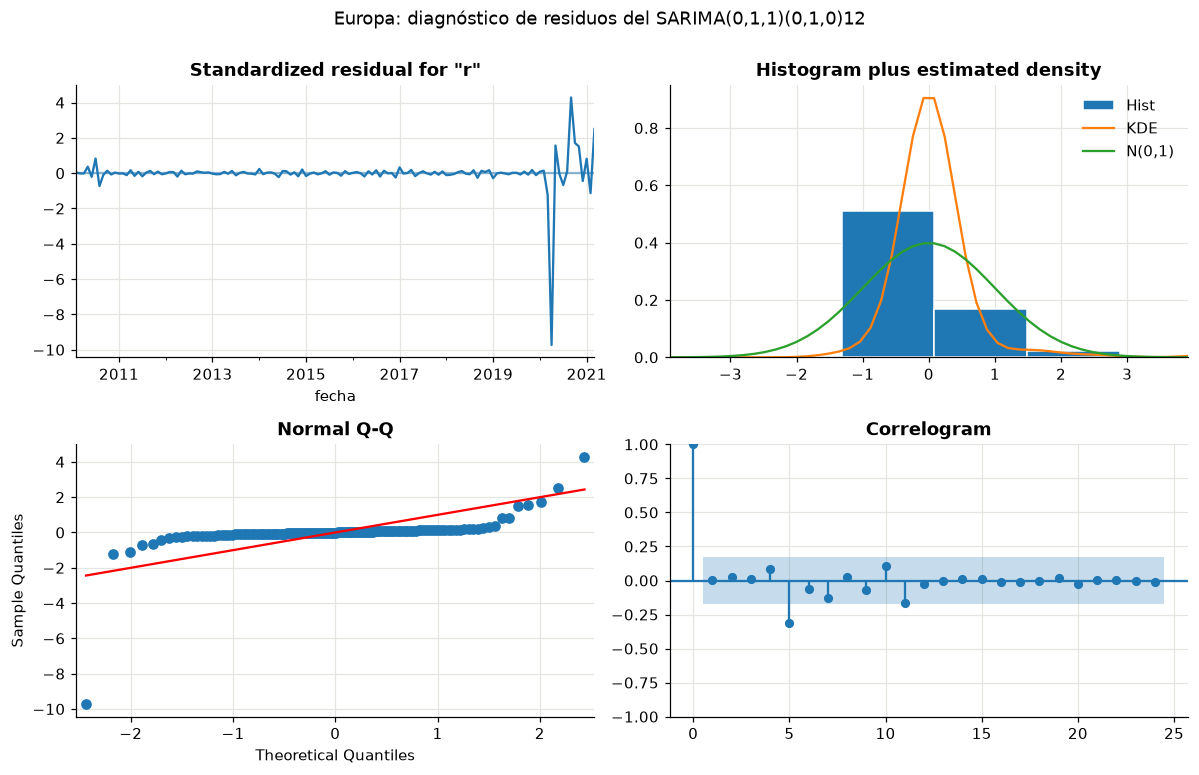

Los tres residuos más grandes (en log(1+x)):
fecha
2020-04-01    8.30
2020-09-01    3.66
2021-03-01    2.13


In [14]:
mejor_europa = ajustes_europa["SARIMA(0, 1, 1)x(0, 1, 0)12"]
diagnostico_residuos(mejor_europa, "Europa: diagnóstico de residuos del SARIMA(0,1,1)(0,1,0)12",
                     "modelado-europa-residuos")
resid = mejor_europa.resid[mejor_europa.loglikelihood_burn:]
print("Los tres residuos más grandes (en log(1+x)):")
print(resid.abs().nlargest(3).round(2).to_string())

El mismo diagnóstico que Norte, algo más leve: **abril de 2020 con 8.3 desviaciones** encabeza,
seguido de septiembre. Los ceros del cierre son la fuente del rezago 12 marginal; el resto del
correlograma está limpio y por eso el rezago 24 sí aprueba. Artefacto de los ceros, no dinámica
sin capturar.

**Elegido para Europa: SARIMA(0,1,1)(0,1,0)₁₂ sobre log(1 + x).**

### 5.3 Contraste con auto_arima

In [15]:
auto_europa = pm.auto_arima(SERIES["region: Europa"], seasonal=True, m=12,
                            stepwise=True, suppress_warnings=True, error_action="ignore")
print(f"Propuesta de auto_arima: ARIMA{auto_europa.order}x{auto_europa.seasonal_order} | AIC {auto_europa.aic():.1f}")
auto_europa.summary().tables[1]

Propuesta de auto_arima: ARIMA(1, 1, 0)x(0, 1, 0, 12) | AIC 341.6


,coef,std err,z,P>|z|,[0.025,0.975]
ar.L1,0.1290,0.054,2.384,0.017,0.023,0.235
sigma2,0.7270,0.018,40.945,0.000,0.692,0.762


En Europa `auto_arima` **coincide con nuestro diagnóstico**: propone un ARIMA(1,1,0)(0,1,0)₁₂,
con la misma diferenciación (d = 1, D = 1) y sin términos estacionales, prácticamente el mismo
modelo que elegimos, apenas cambiando el término regular de MA por AR. Es la confirmación de que,
cuando los ceros impiden que la prueba de raíz unitaria confunda la tendencia, la selección
automática llega al mismo lugar que el análisis manual.

## 6. Resumen del modelado ARIMA de regiones

| Serie | Transform | Modelo elegido | AIC | BIC | Ljung-Box p (12 / 24) |
|---|---|---|---|---|---|
| Total | log | SARIMA(0,1,1)(1,1,0)₁₂ | 64.1 | 72.8 | 0.215 / 0.856 |
| América Del Centro | log | SARIMA(0,1,1)(1,1,0)₁₂ | 50.4 | 59.1 | 0.268 / 0.855 |
| América Del Norte | log(1+x) | SARIMA(0,1,1)(0,1,0)₁₂ | 412.2 | 418.0 | 0.000 / 0.025 |
| Europa | log(1+x) | SARIMA(0,1,1)(0,1,0)₁₂ | 341.6 | 347.4 | 0.021 / 0.454 |

Tres lecturas cierran esta parte.

**Los ceros parten las cuatro series en dos grupos.** El total y América Del Centro, sin ceros,
eligen un modelo con término AR estacional (0,1,1)(1,1,0)₁₂ y dejan residuos limpios que aprueban
Ljung-Box con holgura. América Del Norte y Europa, con cinco meses en cero, eligen el modelo más
simple sin término estacional (0,1,1)(0,1,0)₁₂ y arrastran residuos que fallan o rozan la prueba,
no por mala especificación sino por el bloque pandémico que en log(1 + x) se vuelve un grupo de
residuos enormes. La estructura de fondo es la misma airline en las cuatro; lo que cambia es cuánto
la contamina el cierre.

**auto_arima acertó solo cuando los ceros le impidieron equivocarse.** En el total y en Centro
fue a d = 0, la misma falla de las fronteras: la prueba KPSS lee el colapso como ausencia de
tendencia. En Norte y Europa, donde los ceros vuelven la tendencia inconfundible, diferenció bien;
en Europa incluso coincidió con nuestro modelo, y en Norte propuso órdenes que sobreajustan el
tramo pandémico. La conclusión es la misma que en fronteras: con un cambio de régimen, la
selección automática necesita supervisión.

**Los candidatos del preliminar iban bien encaminados.** En ninguna de las cuatro series la
rejilla encontró algo sustancialmente mejor que el SARIMA(0,1,1)(0,1,1)₁₂ leído de los
correlogramas; los ganadores son variantes menores de ese punto de partida. La diferencia
estacional opcional de América Del Norte quedó confirmada como conveniente, y la obligatoria de
Europa, confirmada como necesaria.

El cuaderno siguiente toma estos cuatro modelos elegidos, los enfrenta a Prophet, Holt-Winters,
suavizamiento exponencial y seasonal naive, y evalúa la predicción sobre el conjunto de prueba.